# MIT-BIH Arrhythmia Database: Exploratory Data Analysis (EDA)

This notebook explores and analyzes the **MIT-BIH Arrhythmia Database (`mitdb`)** from PhysioNet. We will load raw ECG signals, inspect annotations (R-peaks), map them to standard medical classification categories, and design a federated learning data distribution simulation.

In [7]:
import pathlib
import sys, os
sys.path.append(str(pathlib.Path('.').resolve()))
# Helper to save figures in dated subfolders
def save_fig(fig, name, base_dir='assets'):
    import datetime, pathlib
    date_str = datetime.date.today().isoformat()
    target_dir = pathlib.Path(base_dir) / date_str
    target_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'{name}_{timestamp}.png'
    path = target_dir / filename
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    print(f'Figure saved to {path}')
    return str(path)
# Ensure base assets dir exists for compatibility
pathlib.Path('assets').mkdir(exist_ok=True)


## 1. Prerequisites and Setup

We use the `wfdb` (Waveform Database) package to load and parse the PhysioNet format files (`.hea`, `.dat`, `.atr`).

In [8]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define raw data directory
DATA_DIR = os.path.abspath("../../data/raw/mitdb")
print(f"Raw data directory: {DATA_DIR}")
print(f"Exists? {os.path.exists(DATA_DIR)}")
from mit_bih import save_plot


Raw data directory: /Users/bernard/Developer/FORKS/mit-bih/data/raw/mitdb
Exists? True


## 2. Load a Single Patient Record

Let's load the metadata and signal for **Record 100**.

In [9]:
record_name = os.path.join(DATA_DIR, "100")
record = wfdb.rdsamp(record_name)
signals, fields = record

print("Fields metadata:")
for key, val in fields.items():
    print(f"  {key}: {val}")

print(f"\nSignal matrix shape: {signals.shape} (length, channels)")

Fields metadata:
  fs: 360
  sig_len: 650000
  n_sig: 2
  base_date: None
  base_time: None
  units: ['mV', 'mV']
  sig_name: ['MLII', 'V5']
  comments: ['69 M 1085 1629 x1', 'Aldomet, Inderal']

Signal matrix shape: (650000, 2) (length, channels)


## 3. Visualizing Raw ECG Signals

ECG signals are sampled at **360 Hz**. Let's plot a 10-second segment for both channels (typically `MLII` and `V1` or `V5`).

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/raw_ecg_signals_20260625_002517.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/raw_ecg_signals_20260625_002517.txt


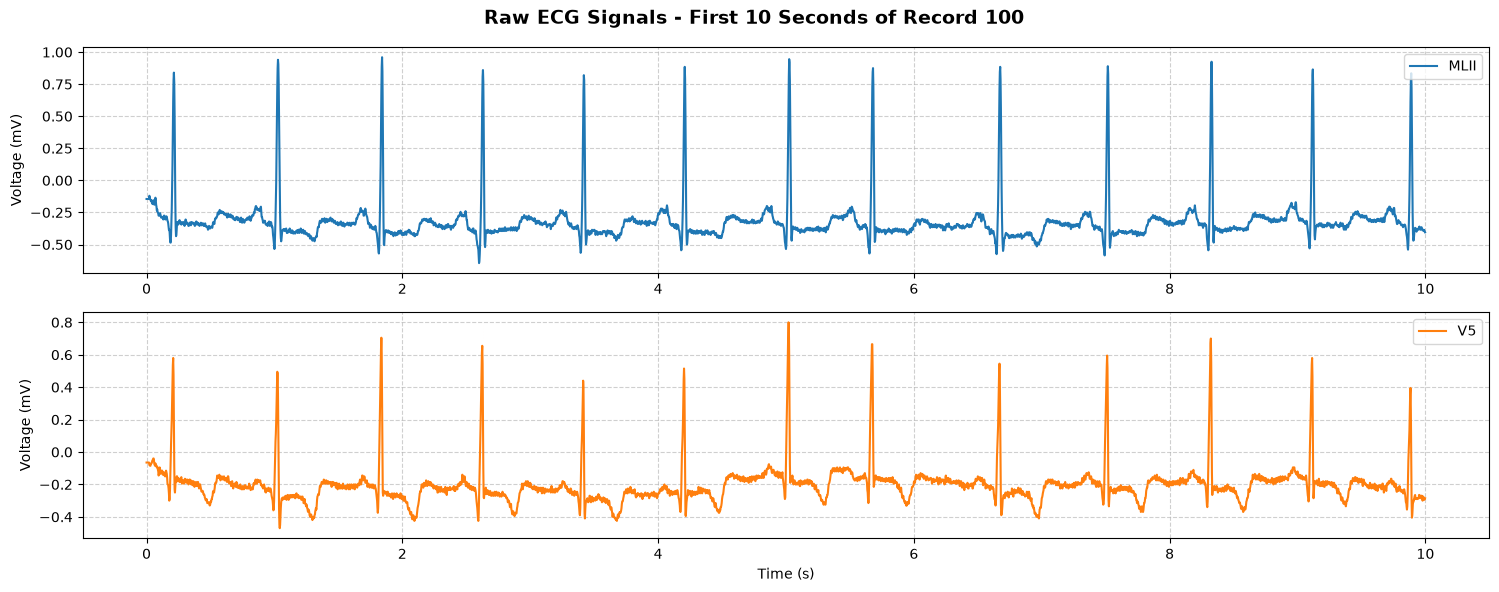

In [10]:
fs = fields['fs']
duration_sec = 10
num_samples = int(fs * duration_sec)

time = np.arange(num_samples) / fs

plt.figure(figsize=(15, 6))
for ch in range(signals.shape[1]):
    plt.subplot(signals.shape[1], 1, ch + 1)
    plt.plot(time, signals[:num_samples, ch], label=fields['sig_name'][ch], color='tab:blue' if ch==0 else 'tab:orange')
    plt.ylabel("Voltage (mV)")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.6)
    if ch == signals.shape[1] - 1:
        plt.xlabel("Time (s)")

plt.suptitle("Raw ECG Signals - First 10 Seconds of Record 100", fontsize=14, fontweight='bold')
plt.tight_layout()
save_plot("raw_ecg_signals", caption="Plot of the first 10 seconds of raw ECG lead signals (MLII and V5) for MIT-BIH Arrhythmia Record 100.")
plt.show()

## 4. Reading Beat Annotations (R-Peaks)

Each record includes beat annotations (`.atr`) containing the sample index where a heartbeat's R-peak is located and the classification symbol given by cardiologists.

In [11]:
ann = wfdb.rdann(record_name, 'atr')
print(f"Total annotations for patient 100: {len(ann.sample)}")
print(f"First 10 R-peak sample indices: {ann.sample[:10]}")
print(f"First 10 beat symbols: {ann.symbol[:10]}")

Total annotations for patient 100: 2274
First 10 R-peak sample indices: [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 beat symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


### Plotting Beat Labels on top of ECG Signals

Let's overlay the symbols on the first 10 seconds of channel 0.

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/ecg_annotations_20260625_002518.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/ecg_annotations_20260625_002518.txt


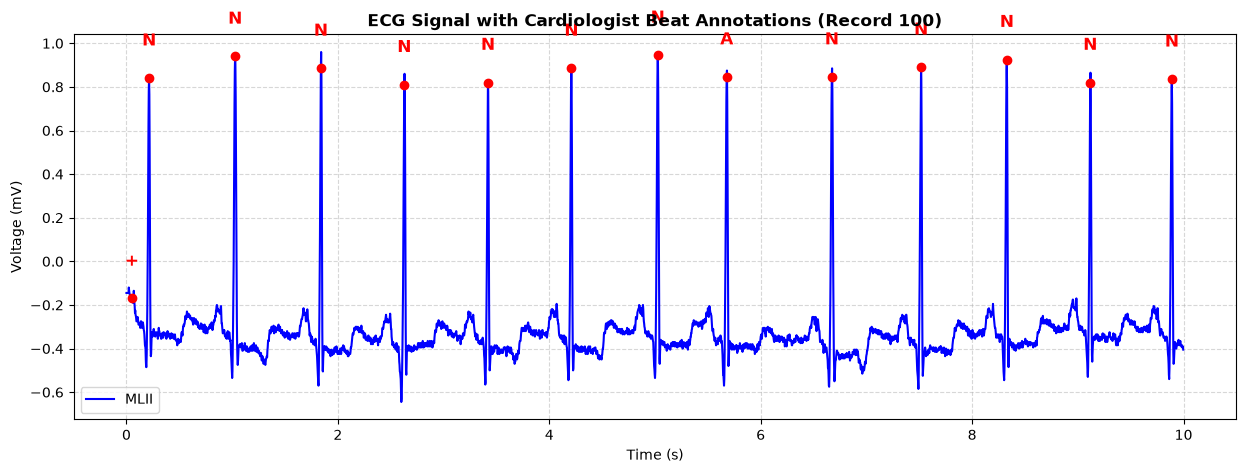

In [12]:
indices_in_window = ann.sample[ann.sample < num_samples]
symbols_in_window = [ann.symbol[i] for i, s in enumerate(ann.sample) if s < num_samples]

plt.figure(figsize=(15, 5))
plt.plot(time, signals[:num_samples, 0], label=fields['sig_name'][0], color='blue')
for idx, sym in zip(indices_in_window, symbols_in_window):
    t_idx = idx / fs
    v_idx = signals[idx, 0]
    plt.plot(t_idx, v_idx, 'ro')
    plt.text(t_idx, v_idx + 0.15, sym, fontsize=12, fontweight='bold', color='red', ha='center')

plt.title("ECG Signal with Cardiologist Beat Annotations (Record 100)", fontsize=12, fontweight='bold')
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
save_plot("ecg_annotations", caption="ECG lead signal from Record 100 overlaid with standard clinician annotations (R-peaks and beat symbols).")
plt.show()

## 5. AAMI Standard Class Mapping

PhysioNet annotations use many fine-grained symbols. According to the Association for the Advancement of Medical Instrumentation (AAMI) standards, these should be grouped into five primary categories:

- **N**: Normal or bundle branch block beats
- **S**: Supraventricular ectopic beats
- **V**: Ventricular ectopic beats
- **F**: Fusion beats
- **Q**: Unknown or unclassifiable beats

In [13]:
AAMI_MAPPING = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

record_ids = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

symbol_counts = {}
aami_counts = {'N': 0, 'S': 0, 'V': 0, 'F': 0, 'Q': 0}

for rid in record_ids[:15]:
    r_path = os.path.join(DATA_DIR, rid)
    if os.path.exists(r_path + ".atr"):
        ann = wfdb.rdann(r_path, 'atr')
        for sym in ann.symbol:
            if sym in AAMI_MAPPING:
                symbol_counts[sym] = symbol_counts.get(sym, 0) + 1
                aami_cls = AAMI_MAPPING[sym]
                aami_counts[aami_cls] += 1

print("PhysioNet Symbol Counts:")
print(symbol_counts)
print("\nAAMI Class Distribution:")
print(aami_counts)

PhysioNet Symbol Counts:
{'N': 20314, 'A': 54, 'V': 726, 'Q': 25, '/': 5486, 'f': 722, 'F': 8, 'j': 1, 'L': 4615, 'a': 6, 'J': 2}

AAMI Class Distribution:
{'N': 24930, 'S': 62, 'V': 726, 'F': 8, 'Q': 6233}


### Visualizing Class Imbalance

ECG datasets are heavily imbalanced. Normal beats ('N') dominate the dataset, which presents a challenge when training ML models.

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/aami_class_distribution_20260625_002519.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/aami_class_distribution_20260625_002519.txt


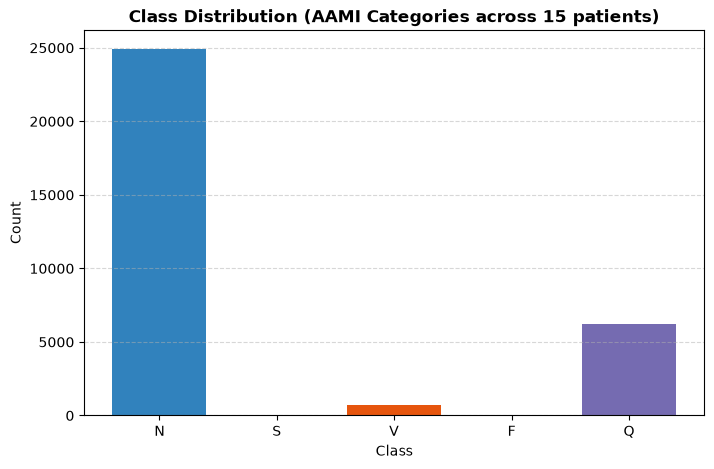

In [14]:
df_aami = pd.DataFrame(list(aami_counts.items()), columns=['Class', 'Count'])

plt.figure(figsize=(8, 5))
plt.bar(df_aami['Class'], df_aami['Count'], color=['#3182bd', '#31a354', '#e6550d', '#de2d26', '#756bb1'])
plt.title("Class Distribution (AAMI Categories across 15 patients)", fontsize=12, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot("aami_class_distribution", caption="Bar plot showing the distribution of heartbeats mapped into the five AAMI standard clinical classes.")
plt.show()

## 6. Federated Learning Simulation Setup: Non-IID Client Data

In federated learning, each client's dataset consists of data collected locally. In a clinical setup, each patient's ECG record represents a single client. 

Because different patients have highly individual heart conditions, the label distribution across client nodes is **Non-IID (Non-Independent and Identically Distributed)**. Let's visualize this heterogeneity across five different patient clients.

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/non_iid_client_distribution_20260625_002519.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/non_iid_client_distribution_20260625_002519.txt


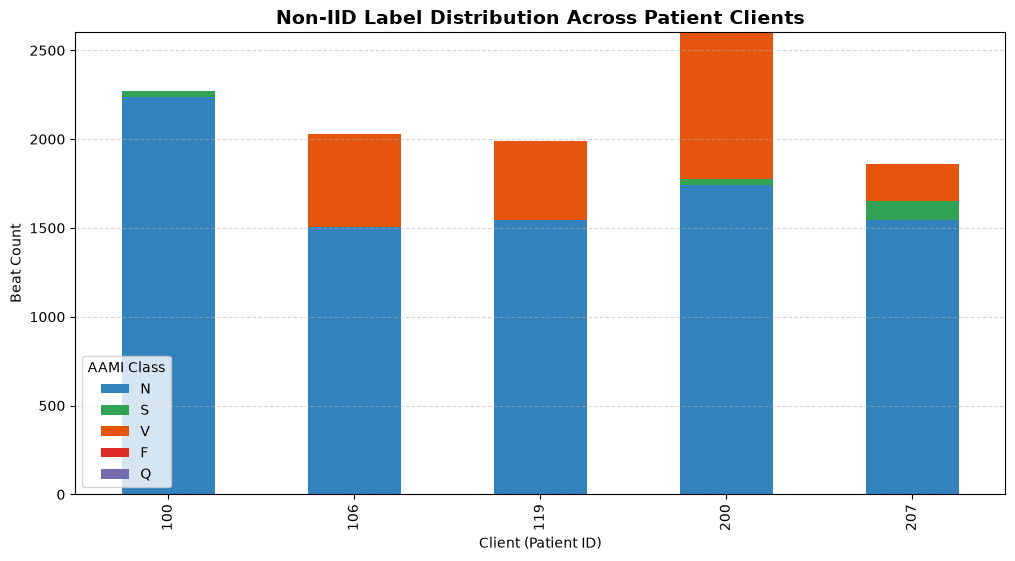

In [15]:
sample_clients = ['100', '106', '119', '200', '207']
client_distributions = {}

for rid in sample_clients:
    r_path = os.path.join(DATA_DIR, rid)
    if os.path.exists(r_path + ".atr"):
        ann = wfdb.rdann(r_path, 'atr')
        counts = {'N': 0, 'S': 0, 'V': 0, 'F': 0, 'Q': 0}
        for sym in ann.symbol:
            if sym in AAMI_MAPPING:
                counts[AAMI_MAPPING[sym]] += 1
        client_distributions[rid] = counts

df_clients = pd.DataFrame(client_distributions).T
df_clients.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#3182bd', '#31a354', '#e6550d', '#de2d26', '#756bb1'])
plt.title("Non-IID Label Distribution Across Patient Clients", fontsize=14, fontweight='bold')
plt.xlabel("Client (Patient ID)")
plt.ylabel("Beat Count")
plt.legend(title="AAMI Class")
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot("non_iid_client_distribution", caption="Stacked bar chart illustrating the non-IID (heterogeneous) class distribution across different patient clients, highlighting the variance in clinical conditions.")
plt.show()

## 7. Conclusions and Next Steps

Through this EDA we have:
1. Explored how to load the signals and oncologist annotations using the `wfdb` library.
2. Visualized ECG traces and aligned annotation peaks on the signal.
3. Grouped raw beat symbols into standardized AAMI classes.
4. Demonstrated that patient data is Non-IID, which makes federated learning training challenging and interesting.

In the next notebook (**`02_data_preprocessing_and_segmentation.ipynb`**), we will clean the noise from the raw signals and segment the continuous streams into individual normalized heartbeats ready for deep learning models.